# ⚡ Power System Fault Detection & Classification
## MYZ307E — Machine Learning for EE | ITU Spring 2025-2026

**Team:** Muhammed Yasir KAMA (040210361) · Kaan KAYALIK (040210443) · Başar KARADAŞ (040210435) · Mert YİLMAZ (040210366)

**Baseline Repos:**
- Repo 1: https://github.com/svdeepak99/Machine_Learning-Power_System_Fault_Detection
- Repo 2: https://github.com/KingArthur000/Electrical-Fault-detection-and-classification

**Reference Paper:** T. Anwar et al., *Robust fault detection and classification via ensemble ML models*, Scientific Reports, 2025. DOI: 10.1038/s41598-025-86554-2


---
## 📦 Bölüm 1: Kütüphaneler & Veri Yükleme

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import VotingClassifier

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
COLORS = sns.color_palette('husl', 10)

print('✅ Kütüphaneler yüklendi.')
print(f'   NumPy: {np.__version__} | Pandas: {pd.__version__}')

✅ Kütüphaneler yüklendi.
   NumPy: 2.0.2 | Pandas: 2.2.2


In [2]:
# ── Veri Yükleme ──
detect_df = pd.read_csv(
    'https://raw.githubusercontent.com/svdeepak99/Machine_Learning-Power_System_Fault_Detection/main/powerline_dataset.csv'
)
class_df = pd.read_csv(
    'https://raw.githubusercontent.com/KingArthur000/Electrical-Fault-detection-and-classification/main/classData.csv'
)

# ── Detection Dataset Temizleme ──
# Unnamed boş sütunları at
detect_df = detect_df.loc[:, ~detect_df.columns.str.startswith('Unnamed')]
detect_df.columns = detect_df.columns.str.strip()
class_df.columns  = class_df.columns.str.strip()

print('📂 Datasetler:')
print(f'   Detection     → {detect_df.shape[0]:,} satır × {detect_df.shape[1]} sütun')
print(f'   Classification → {class_df.shape[0]:,} satır × {class_df.shape[1]} sütun')
print(f'\n   Detection sütunları  : {detect_df.columns.tolist()}')
print(f'   Classification sütunları: {class_df.columns.tolist()}')

📂 Datasetler:
   Detection     → 12,001 satır × 7 sütun
   Classification → 7,861 satır × 10 sütun

   Detection sütunları  : ['Output (S)', 'Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']
   Classification sütunları: ['G', 'C', 'B', 'A', 'Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']


In [3]:
# ── Feature / Target Ayırma ──
FEAT_COLS = ['Ia','Ib','Ic','Va','Vb','Vc']

# Detection
X_det = detect_df[FEAT_COLS].values
y_det = detect_df['Output (S)'].values

# Classification — DOĞRU fault mapping
print('Veri setindeki [G,C,B,A] kombinasyonları:')
print(class_df[['G','C','B','A']].value_counts().sort_index())

# DÜZELTME: LL fault doğru kombinasyon (0,1,1,0) — eski (0,0,1,1) yanlıştı
fault_map = {
    (0,0,0,0): 0,  # No Fault
    (1,0,0,1): 1,  # LG
    (0,1,1,0): 2,  # LL  <-- DÜZELTİLDİ
    (1,0,1,1): 3,  # LLG
    (0,1,1,1): 4,  # LLL
    (1,1,1,1): 5,  # LLLG
}
fault_names = ['No Fault','LG','LL','LLG','LLL','LLLG']

y_cls_raw = class_df[['G','C','B','A']].apply(
    lambda row: fault_map.get(tuple(row.astype(int)), -1), axis=1
).values

# Mapping dogruysa -1 olmamali; varsa hata ver
if np.any(y_cls_raw == -1):
    print('Bilinmeyen [G,C,B,A] kombinasyonlari:')
    print(class_df.loc[y_cls_raw == -1, ['G','C','B','A']].drop_duplicates())
    raise ValueError('Fault mapping hatali! -1 class kalmamali.')

X_cls = class_df[FEAT_COLS].values
y_cls = y_cls_raw

n0 = int(np.sum(y_det==0))
n1 = int(np.sum(y_det==1))
print(f'\nDetection  X:{X_det.shape} | Normal:{n0} ({n0/len(y_det)*100:.1f}%) | Fault:{n1} ({n1/len(y_det)*100:.1f}%)')
print(f'Classification  X:{X_cls.shape}')
for idx, name in enumerate(fault_names):
    print(f'  {idx} - {name}: {int(np.sum(y_cls==idx))}')


Veri setindeki [G,C,B,A] kombinasyonları:
G  C  B  A
0  0  0  0    2365
   1  1  0    1004
         1    1096
1  0  0  1    1129
      1  1    1134
   1  1  1    1133
Name: count, dtype: int64

Detection  X:(12001, 6) | Normal:6505 (54.2%) | Fault:5496 (45.8%)
Classification  X:(7861, 6)
  0 - No Fault: 2365
  1 - LG: 1129
  2 - LL: 1004
  3 - LLG: 1134
  4 - LLL: 1096
  5 - LLLG: 1133


---
## 📊 Bölüm 2: Keşifsel Veri Analizi (EDA)

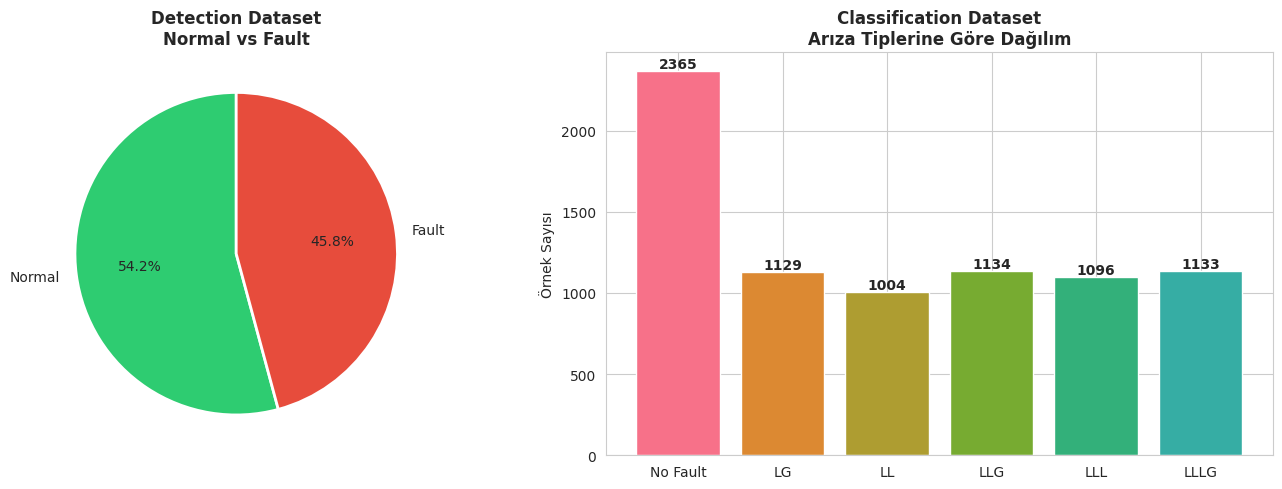

In [4]:
# ── 2.1 Sınıf Dağılımları ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Detection
det_counts = pd.Series(y_det).value_counts().sort_index()
axes[0].pie(det_counts, labels=['Normal','Fault'],
            autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Detection Dataset\nNormal vs Fault', fontweight='bold')

# Classification
cls_counts = pd.Series(y_cls).value_counts().sort_index()
active_names = [fault_names[i] for i in sorted(np.unique(y_cls))]
bars = axes[1].bar(active_names, [cls_counts.get(i,0) for i in sorted(np.unique(y_cls))],
                   color=COLORS[:len(active_names)], edgecolor='white')
axes[1].set_title('Classification Dataset\nArıza Tiplerine Göre Dağılım', fontweight='bold')
axes[1].set_ylabel('Örnek Sayısı')
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                 str(int(bar.get_height())), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

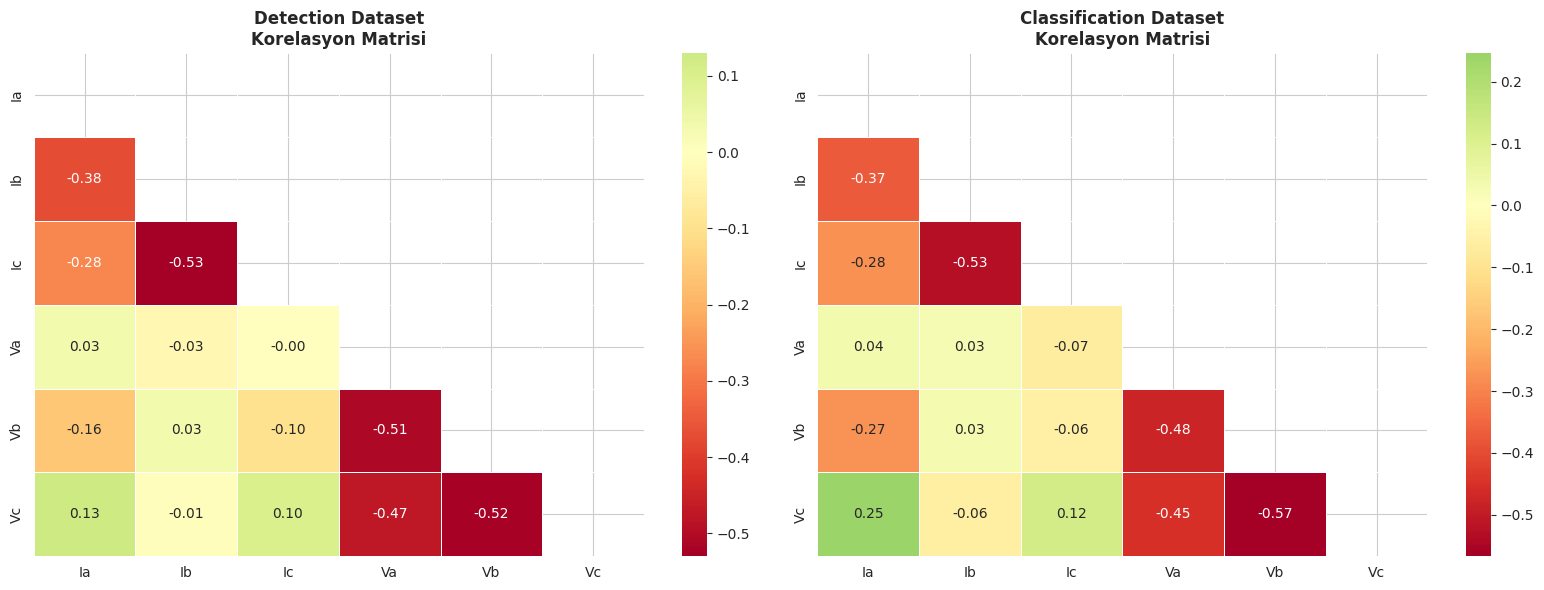

In [5]:
# ── 2.2 Korelasyon Matrisi ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, df, title in zip(axes,
    [detect_df[FEAT_COLS], class_df[FEAT_COLS]],
    ['Detection Dataset', 'Classification Dataset']):
    corr = df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, ax=ax, mask=mask, annot=True, fmt='.2f',
                cmap='RdYlGn', center=0, linewidths=0.5)
    ax.set_title(f'{title}\nKorelasyon Matrisi', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔍 Bölüm 3: Fault Detection — 8 Model + Voting Ensemble

In [6]:
# ── Train/Test Split & Scaling ──
X_det_train, X_det_test, y_det_train, y_det_test = train_test_split(
    X_det, y_det, test_size=0.2, random_state=42, stratify=y_det
)
scaler_det = StandardScaler()
X_det_train_sc = scaler_det.fit_transform(X_det_train)
X_det_test_sc  = scaler_det.transform(X_det_test)
print(f'Train: {X_det_train_sc.shape} | Test: {X_det_test_sc.shape}')

Train: (9600, 6) | Test: (2401, 6)


In [7]:
# ── 8 Model Eğitimi ──
detection_models = {
    'SVM (RBF)'          : SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=14, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'KNN (k=5)'          : KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Naive Bayes'        : GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'MLP (relu+Adam)'    : MLPClassifier(hidden_layer_sizes=(128,64), activation='relu',
                                          solver='adam', max_iter=500, random_state=42),
}

det_results = {}
print('Detection modelleri eğitiliyor...')
print(f'{"Model":<22} {"Accuracy":>10} {"F1":>10} {"Precision":>10} {"Recall":>10}')
print('-'*65)

for name, model in detection_models.items():
    model.fit(X_det_train_sc, y_det_train)
    y_pred = model.predict(X_det_test_sc)
    acc  = accuracy_score(y_det_test, y_pred)
    f1   = f1_score(y_det_test, y_pred, average='weighted')
    prec = precision_score(y_det_test, y_pred, average='weighted')
    rec  = recall_score(y_det_test, y_pred, average='weighted')
    det_results[name] = {'Accuracy':acc,'F1':f1,'Precision':prec,'Recall':rec,'model':model}
    print(f'{name:<22} {acc*100:>9.2f}% {f1*100:>9.2f}% {prec*100:>9.2f}% {rec*100:>9.2f}%')

print('-'*65)

Detection modelleri eğitiliyor...
Model                    Accuracy         F1  Precision     Recall
-----------------------------------------------------------------
SVM (RBF)                  99.58%     99.58%     99.58%     99.58%
Decision Tree              99.58%     99.58%     99.58%     99.58%
Random Forest              99.63%     99.63%     99.63%     99.63%
KNN (k=5)                  99.67%     99.67%     99.67%     99.67%
Naive Bayes                97.42%     97.41%     97.54%     97.42%
Logistic Regression        71.30%     67.76%     81.24%     71.30%
Gradient Boosting          99.67%     99.67%     99.67%     99.67%
MLP (relu+Adam)            99.50%     99.50%     99.50%     99.50%
-----------------------------------------------------------------


In [8]:
# ── Voting Ensemble (RF + SVM + GB) ──
voting_det = VotingClassifier(
    estimators=[
        ('rf',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
        ('svm', SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)),
        ('gb',  GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ],
    voting='soft'
)
voting_det.fit(X_det_train_sc, y_det_train)
y_vote_det = voting_det.predict(X_det_test_sc)

vote_det_acc  = accuracy_score(y_det_test, y_vote_det)
vote_det_f1   = f1_score(y_det_test, y_vote_det, average='weighted')
vote_det_prec = precision_score(y_det_test, y_vote_det, average='weighted')
vote_det_rec  = recall_score(y_det_test, y_vote_det, average='weighted')

det_results['Voting Ensemble'] = {
    'Accuracy': vote_det_acc, 'F1': vote_det_f1,
    'Precision': vote_det_prec, 'Recall': vote_det_rec, 'model': voting_det
}

print(f'🏆 Voting Ensemble (RF+SVM+GB): Accuracy={vote_det_acc*100:.2f}%  F1={vote_det_f1*100:.2f}%')

🏆 Voting Ensemble (RF+SVM+GB): Accuracy=99.75%  F1=99.75%



📊 DETECTION SONUÇLARI (Sıralı):
              Model  Accuracy        F1  Precision    Recall
    Voting Ensemble 99.750104 99.750121  99.750278 99.750104
  Gradient Boosting 99.666805 99.666829  99.666991 99.666805
          KNN (k=5) 99.666805 99.666829  99.666991 99.666805
      Random Forest 99.625156 99.625143  99.625165 99.625156
          SVM (RBF) 99.583507 99.583507  99.583507 99.583507
      Decision Tree 99.583507 99.583536  99.583704 99.583507
    MLP (relu+Adam) 99.500208 99.500173  99.500276 99.500208
        Naive Bayes 97.417743 97.410350  97.535204 97.417743
Logistic Regression 71.303623 67.764922  81.239203 71.303623


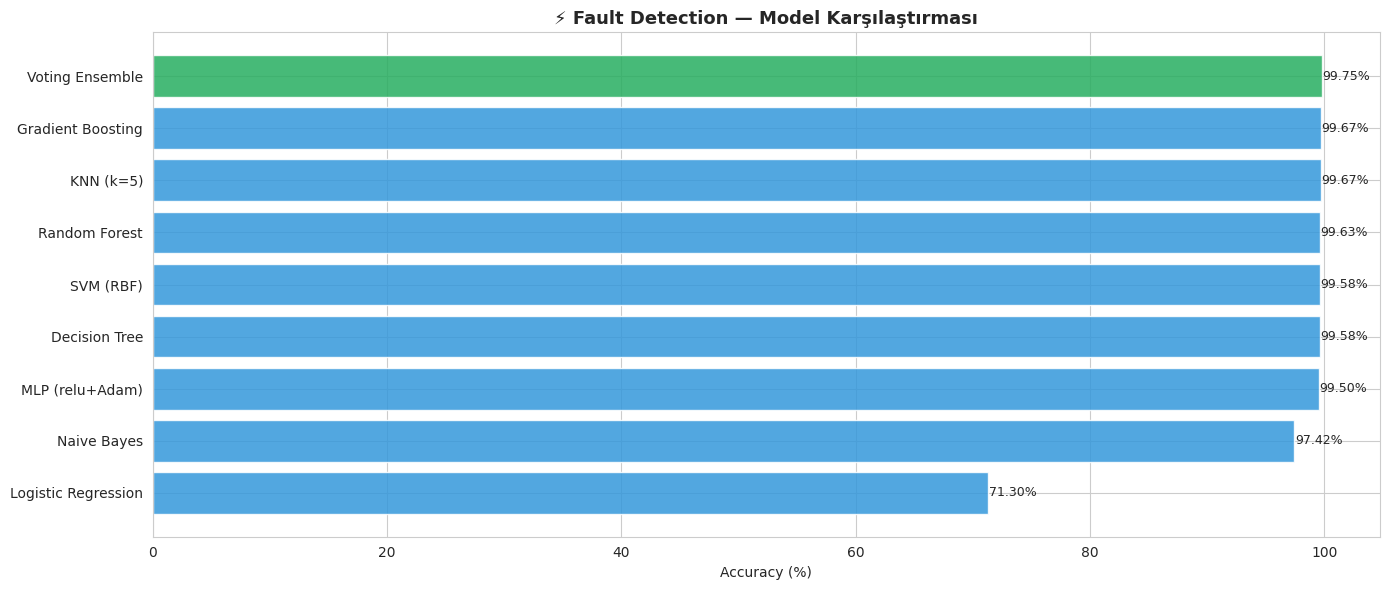


🏆 En iyi Detection modeli: Voting Ensemble (99.75%)


In [9]:
# ── Detection Sonuç Grafiği ──
summary_detection = pd.DataFrame([
    {'Model':k,'Accuracy':v['Accuracy']*100,'F1':v['F1']*100,
     'Precision':v['Precision']*100,'Recall':v['Recall']*100}
    for k,v in det_results.items()
]).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print('\n📊 DETECTION SONUÇLARI (Sıralı):')
print(summary_detection[['Model','Accuracy','F1','Precision','Recall']].to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(14,6))
colors = ['#27ae60' if m=='Voting Ensemble' else '#3498db' for m in summary_detection['Model']]
bars = ax.barh(summary_detection['Model'][::-1], summary_detection['Accuracy'][::-1],
               color=colors[::-1], alpha=0.85)
ax.set_xlabel('Accuracy (%)')
ax.set_title('⚡ Fault Detection — Model Karşılaştırması', fontsize=13, fontweight='bold')
for bar in bars:
    ax.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():.2f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

best_det_name = summary_detection.iloc[0]['Model']
best_det_acc  = summary_detection.iloc[0]['Accuracy']
print(f'\n🏆 En iyi Detection modeli: {best_det_name} ({best_det_acc:.2f}%)')

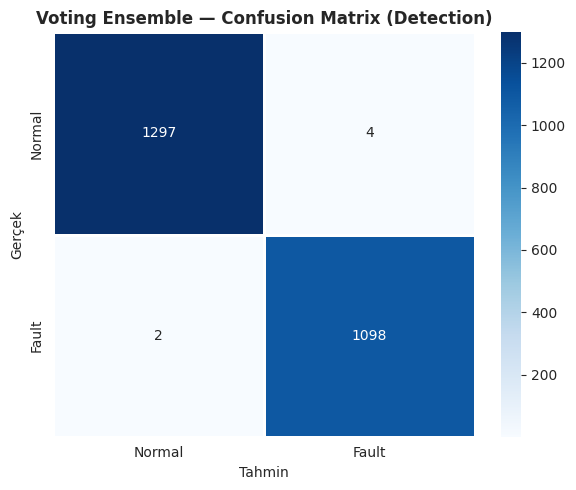

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      1301
       Fault       1.00      1.00      1.00      1100

    accuracy                           1.00      2401
   macro avg       1.00      1.00      1.00      2401
weighted avg       1.00      1.00      1.00      2401



In [10]:
# ── En İyi Model — Confusion Matrix ──
best_det_model = det_results[best_det_name]['model']
y_pred_best_det = best_det_model.predict(X_det_test_sc)
cm = confusion_matrix(y_det_test, y_pred_best_det)

fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal','Fault'], yticklabels=['Normal','Fault'],
            linewidths=1, linecolor='white')
ax.set_title(f'{best_det_name} — Confusion Matrix (Detection)', fontweight='bold')
ax.set_ylabel('Gerçek'); ax.set_xlabel('Tahmin')
plt.tight_layout(); plt.show()

print(classification_report(y_det_test, y_pred_best_det, target_names=['Normal','Fault']))

---
## 🔬 Bölüm 4: PCA ile Boyut İndirgeme

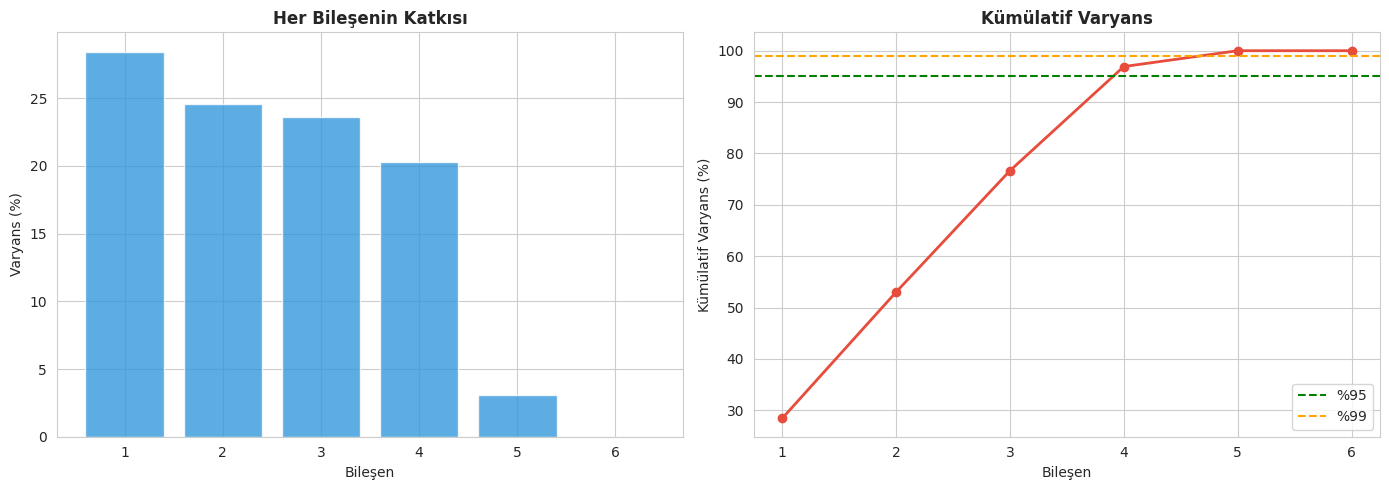

%95 varyans için: 4 bileşen
%99 varyans için: 5 bileşen
  1 bileşen: 28.45% kümülatif varyans
  2 bileşen: 53.02% kümülatif varyans
  3 bileşen: 76.65% kümülatif varyans
  4 bileşen: 96.92% kümülatif varyans
  5 bileşen: 100.00% kümülatif varyans
  6 bileşen: 100.00% kümülatif varyans


In [11]:
# ── PCA Explained Variance ──
pca_full = PCA()
pca_full.fit(X_det_train_sc)
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100

n_95 = int(np.argmax(cumvar >= 95) + 1)
n_99 = int(np.argmax(cumvar >= 99) + 1)

fig, axes = plt.subplots(1,2, figsize=(14,5))
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_*100, color='#3498db', alpha=0.8)
axes[0].set_xlabel('Bileşen'); axes[0].set_ylabel('Varyans (%)')
axes[0].set_title('Her Bileşenin Katkısı', fontweight='bold')

axes[1].plot(range(1, len(cumvar)+1), cumvar, 'o-', color='#e74c3c', lw=2)
axes[1].axhline(95, color='green', ls='--', label='%95')
axes[1].axhline(99, color='orange', ls='--', label='%99')
axes[1].set_xlabel('Bileşen'); axes[1].set_ylabel('Kümülatif Varyans (%)')
axes[1].set_title('Kümülatif Varyans', fontweight='bold')
axes[1].legend()
plt.tight_layout(); plt.show()

print(f'%95 varyans için: {n_95} bileşen')
print(f'%99 varyans için: {n_99} bileşen')
for i, v in enumerate(cumvar):
    print(f'  {i+1} bileşen: {v:.2f}% kümülatif varyans')

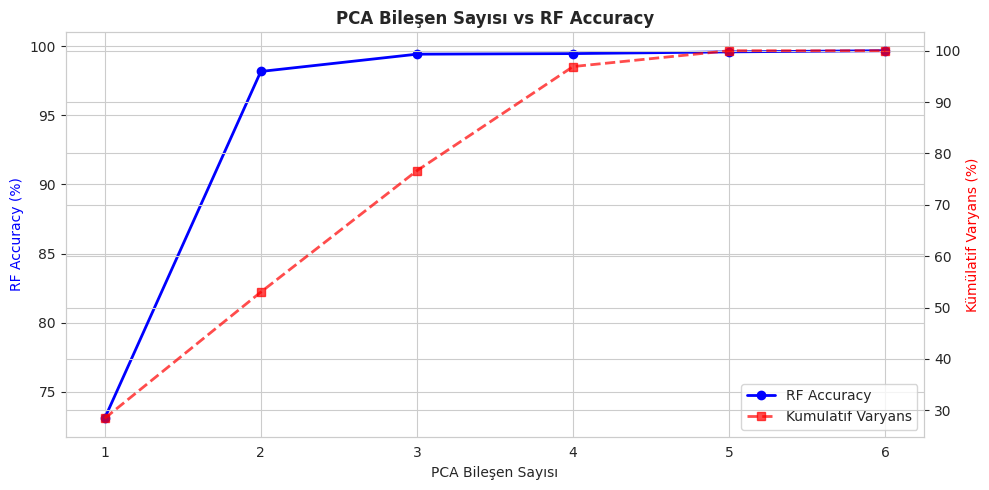

PCA Detaylı Sonuçlar:
 n       acc        var
 1 73.094544  28.448485
 2 98.167430  53.021379
 3 99.416910  76.652346
 4 99.458559  96.915896
 5 99.583507 100.000000
 6 99.666805 100.000000


In [12]:
# ── PCA + RF Accuracy vs Bileşen Sayısı ──
pca_results = []
for n in range(1, X_det_train_sc.shape[1]+1):
    pca = PCA(n_components=n)
    X_tr_pca = pca.fit_transform(X_det_train_sc)
    X_te_pca = pca.transform(X_det_test_sc)
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_tr_pca, y_det_train)
    acc = accuracy_score(y_det_test, rf.predict(X_te_pca))
    pca_results.append({'n':n, 'acc':acc*100, 'var':cumvar[n-1]})

pca_df = pd.DataFrame(pca_results)

fig, ax1 = plt.subplots(figsize=(10,5))
ax2 = ax1.twinx()
ax1.plot(pca_df['n'], pca_df['acc'], 'b-o', lw=2, label='RF Accuracy')
ax2.plot(pca_df['n'], pca_df['var'], 'r--s', lw=2, alpha=0.7, label='Kümülatif Varyans')
ax1.set_xlabel('PCA Bileşen Sayısı')
ax1.set_ylabel('RF Accuracy (%)', color='blue')
ax2.set_ylabel('Kümülatif Varyans (%)', color='red')
ax1.set_title('PCA Bileşen Sayısı vs RF Accuracy', fontweight='bold')
lines1,l1 = ax1.get_legend_handles_labels()
lines2,l2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, l1+l2, loc='lower right')
plt.tight_layout(); plt.show()

print('PCA Detaylı Sonuçlar:')
print(pca_df.to_string(index=False))
n_components_95 = n_95

---
## ⚡ Bölüm 5: Fault Classification — 6 Arıza Tipi

In [13]:
# ── Train/Test Split & Scaling ──
X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)
scaler_cls = StandardScaler()
X_cls_train_sc = scaler_cls.fit_transform(X_cls_train)
X_cls_test_sc  = scaler_cls.transform(X_cls_test)
print(f'Train: {X_cls_train_sc.shape} | Test: {X_cls_test_sc.shape}')

active_fault_names = [fault_names[i] for i in sorted(np.unique(y_cls))]

Train: (6288, 6) | Test: (1573, 6)


In [14]:
# ── 8 Classification Modeli ──
classification_models = {
    'SVM (RBF)'          : SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=14, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'KNN (k=5)'          : KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Naive Bayes'        : GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'MLP (relu+Adam)'    : MLPClassifier(hidden_layer_sizes=(128,64), activation='relu',
                                          solver='adam', max_iter=500, random_state=42),
}

cls_results = {}
print('Classification modelleri eğitiliyor...')
print(f'{"Model":<22} {"Accuracy":>10} {"F1":>10} {"Precision":>10} {"Recall":>10}')
print('-'*65)

for name, model in classification_models.items():
    model.fit(X_cls_train_sc, y_cls_train)
    y_pred = model.predict(X_cls_test_sc)
    acc  = accuracy_score(y_cls_test, y_pred)
    f1   = f1_score(y_cls_test, y_pred, average='weighted')
    prec = precision_score(y_cls_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_cls_test, y_pred, average='weighted')
    cls_results[name] = {'Accuracy':acc,'F1':f1,'Precision':prec,'Recall':rec,'model':model}
    print(f'{name:<22} {acc*100:>9.2f}% {f1*100:>9.2f}% {prec*100:>9.2f}% {rec*100:>9.2f}%')

print('-'*65)

Classification modelleri eğitiliyor...
Model                    Accuracy         F1  Precision     Recall
-----------------------------------------------------------------
SVM (RBF)                  83.98%     83.81%     83.67%     83.98%
Decision Tree              85.76%     85.59%     85.83%     85.76%
Random Forest              88.24%     88.24%     88.26%     88.24%
KNN (k=5)                  79.28%     79.18%     79.10%     79.28%
Naive Bayes                79.40%     77.11%     77.50%     79.40%
Logistic Regression        34.27%     21.38%     29.13%     34.27%
Gradient Boosting          84.04%     84.01%     84.04%     84.04%
MLP (relu+Adam)            84.23%     84.23%     84.27%     84.23%
-----------------------------------------------------------------


In [15]:
# ── Voting Ensemble (Classification) ──
voting_cls = VotingClassifier(
    estimators=[
        ('rf',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
        ('svm', SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)),
        ('gb',  GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ],
    voting='soft'
)
voting_cls.fit(X_cls_train_sc, y_cls_train)
y_vote_cls = voting_cls.predict(X_cls_test_sc)

vote_cls_acc  = accuracy_score(y_cls_test, y_vote_cls)
vote_cls_f1   = f1_score(y_cls_test, y_vote_cls, average='weighted')
vote_cls_prec = precision_score(y_cls_test, y_vote_cls, average='weighted', zero_division=0)
vote_cls_rec  = recall_score(y_cls_test, y_vote_cls, average='weighted')

cls_results['Voting Ensemble'] = {
    'Accuracy':vote_cls_acc,'F1':vote_cls_f1,
    'Precision':vote_cls_prec,'Recall':vote_cls_rec,'model':voting_cls
}
print(f'🏆 Voting Ensemble: Accuracy={vote_cls_acc*100:.2f}%  F1={vote_cls_f1*100:.2f}%')

🏆 Voting Ensemble: Accuracy=87.48%  F1=87.46%



📊 CLASSIFICATION SONUÇLARI (Sıralı):
              Model  Accuracy        F1  Precision    Recall
      Random Forest 88.239034 88.235230  88.260990 88.239034
    Voting Ensemble 87.476160 87.461101  87.452759 87.476160
      Decision Tree 85.759695 85.591426  85.828192 85.759695
    MLP (relu+Adam) 84.233948 84.227138  84.268694 84.233948
  Gradient Boosting 84.043229 84.012563  84.037244 84.043229
          SVM (RBF) 83.979657 83.807597  83.671864 83.979657
        Naive Bayes 79.402416 77.106082  77.503473 79.402416
          KNN (k=5) 79.275270 79.180282  79.095475 79.275270
Logistic Regression 34.265734 21.375604  29.125914 34.265734

🏆 En iyi Classification modeli: Random Forest (88.24%)


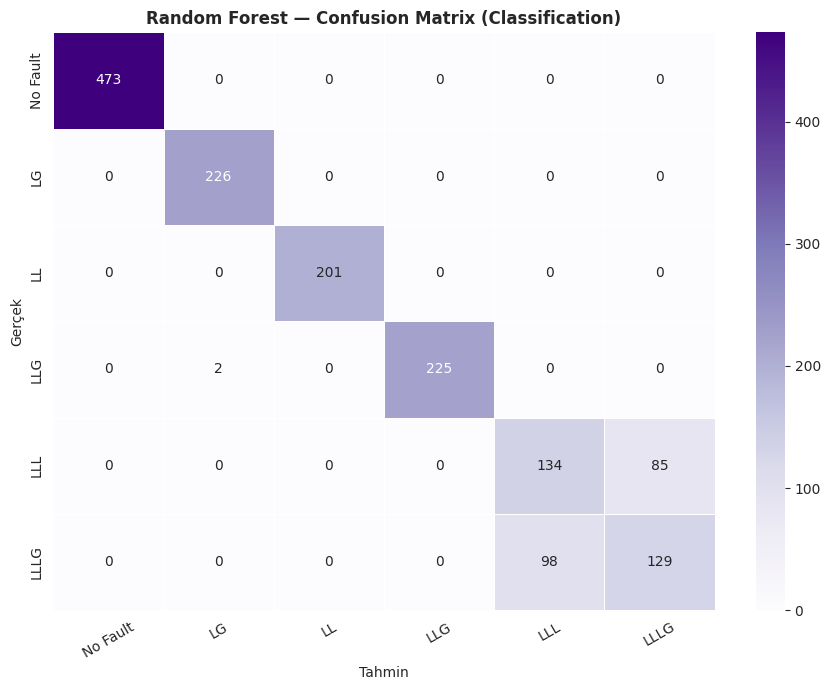

              precision    recall  f1-score   support

    No Fault       1.00      1.00      1.00       473
          LG       0.99      1.00      1.00       226
          LL       1.00      1.00      1.00       201
         LLG       1.00      0.99      1.00       227
         LLL       0.58      0.61      0.59       219
        LLLG       0.60      0.57      0.59       227

    accuracy                           0.88      1573
   macro avg       0.86      0.86      0.86      1573
weighted avg       0.88      0.88      0.88      1573



In [16]:
# ── Classification Sonuçları & Confusion Matrix ──
summary_classification = pd.DataFrame([
    {'Model':k,'Accuracy':v['Accuracy']*100,'F1':v['F1']*100,
     'Precision':v['Precision']*100,'Recall':v['Recall']*100}
    for k,v in cls_results.items()
]).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print('\n📊 CLASSIFICATION SONUÇLARI (Sıralı):')
print(summary_classification[['Model','Accuracy','F1','Precision','Recall']].to_string(index=False))

best_cls_name = summary_classification.iloc[0]['Model']
best_cls_acc  = summary_classification.iloc[0]['Accuracy']
print(f'\n🏆 En iyi Classification modeli: {best_cls_name} ({best_cls_acc:.2f}%)')

# Confusion Matrix
best_cls_model = cls_results[best_cls_name]['model']
y_pred_best_cls = best_cls_model.predict(X_cls_test_sc)
cm_cls = confusion_matrix(y_cls_test, y_pred_best_cls)

fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(cm_cls, annot=True, fmt='d', cmap='Purples', ax=ax,
            xticklabels=active_fault_names, yticklabels=active_fault_names,
            linewidths=0.5)
ax.set_title(f'{best_cls_name} — Confusion Matrix (Classification)', fontweight='bold')
ax.set_ylabel('Gerçek'); ax.set_xlabel('Tahmin')
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

print(classification_report(y_cls_test, y_pred_best_cls, target_names=active_fault_names, zero_division=0))

---
## 🌀 Bölüm 6: GMM Anomali Tespiti (Unsupervised)

In [17]:
# ── GMM Grid Search ──
normal_mask_train = (y_det_train == 0)
X_normal_train = X_det_train_sc[normal_mask_train]

gmm_results = []
print('GMM Grid Search (32 konfigürasyon)...')

for n_comp in range(1, 9):
    for cov in ['full','tied','diag','spherical']:
        gmm = GaussianMixture(n_components=n_comp, covariance_type=cov,
                              random_state=42, max_iter=200)
        gmm.fit(X_normal_train)
        threshold = np.percentile(gmm.score_samples(X_normal_train), 5)
        scores_test = gmm.score_samples(X_det_test_sc)
        y_gmm_pred_tmp = (scores_test < threshold).astype(int)
        acc = accuracy_score(y_det_test, y_gmm_pred_tmp)
        gmm_results.append({'n_comp':n_comp,'cov':cov,'acc':acc})

gmm_df = pd.DataFrame(gmm_results)
best_gmm_row = gmm_df.loc[gmm_df['acc'].idxmax()]
best_gmm_n   = int(best_gmm_row['n_comp'])
best_gmm_cov = str(best_gmm_row['cov'])
best_gmm_acc = float(best_gmm_row['acc'])

print(f'✅ En iyi GMM: n_components={best_gmm_n}, covariance_type={best_gmm_cov}')
print(f'   Accuracy: {best_gmm_acc*100:.2f}%')

GMM Grid Search (32 konfigürasyon)...
✅ En iyi GMM: n_components=2, covariance_type=full
   Accuracy: 98.08%


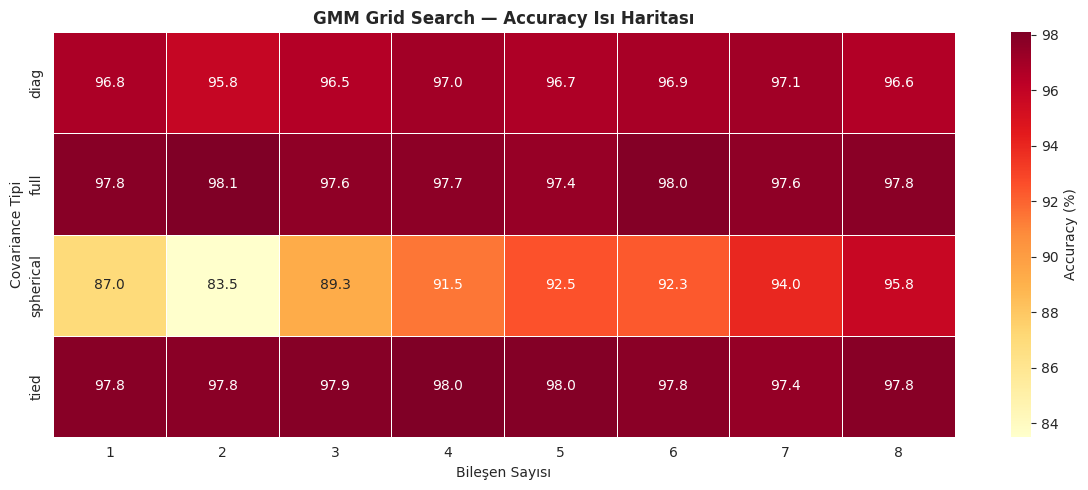

In [18]:
# ── GMM Grid Search Isı Haritası ──
gmm_pivot = gmm_df.pivot(index='cov', columns='n_comp', values='acc') * 100
fig, ax = plt.subplots(figsize=(12,5))
sns.heatmap(gmm_pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label':'Accuracy (%)'})
ax.set_title('GMM Grid Search — Accuracy Isı Haritası', fontweight='bold')
ax.set_xlabel('Bileşen Sayısı'); ax.set_ylabel('Covariance Tipi')
plt.tight_layout(); plt.show()

GMM Optimal Config : n=2, cov=full
GMM Threshold       : 6.9327
GMM Accuracy        : 98.08%
              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98      1301
       Fault       0.96      1.00      0.98      1100

    accuracy                           0.98      2401
   macro avg       0.98      0.98      0.98      2401
weighted avg       0.98      0.98      0.98      2401



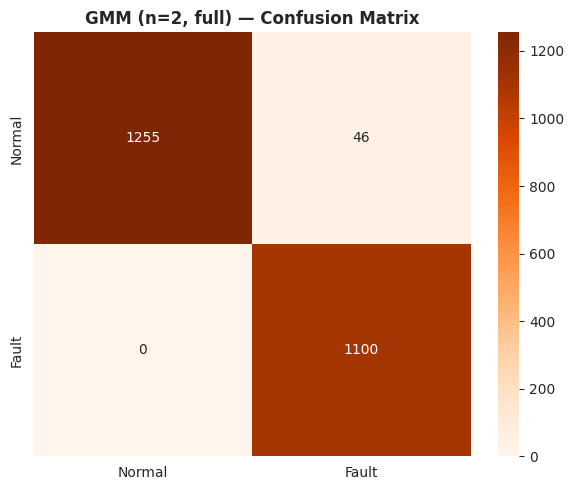

In [19]:
# ── Final GMM Tahmin & Confusion Matrix ──
best_gmm_model = GaussianMixture(
    n_components=best_gmm_n,
    covariance_type=best_gmm_cov,
    random_state=42, max_iter=200
)
best_gmm_model.fit(X_normal_train)
gmm_threshold = np.percentile(best_gmm_model.score_samples(X_normal_train), 5)
gmm_scores    = best_gmm_model.score_samples(X_det_test_sc)
y_gmm_pred    = (gmm_scores < gmm_threshold).astype(int)
gmm_final_acc = accuracy_score(y_det_test, y_gmm_pred)

print(f'GMM Optimal Config : n={best_gmm_n}, cov={best_gmm_cov}')
print(f'GMM Threshold       : {gmm_threshold:.4f}')
print(f'GMM Accuracy        : {gmm_final_acc*100:.2f}%')
print(classification_report(y_det_test, y_gmm_pred, target_names=['Normal','Fault']))

fig, ax = plt.subplots(figsize=(6,5))
cm_gmm = confusion_matrix(y_det_test, y_gmm_pred)
sns.heatmap(cm_gmm, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=['Normal','Fault'], yticklabels=['Normal','Fault'])
ax.set_title(f'GMM (n={best_gmm_n}, {best_gmm_cov}) — Confusion Matrix', fontweight='bold')
plt.tight_layout(); plt.show()

---
## 🔬 Bölüm 7: Ablation Study — Feature Importance

Baseline (all features): 99.63%
Remove Ia: 99.46% (Δ-0.17%)
Remove Ib: 99.67% (Δ+0.04%)
Remove Ic: 99.58% (Δ-0.04%)
Remove Va: 99.58% (Δ-0.04%)
Remove Vb: 99.54% (Δ-0.08%)
Remove Vc: 99.58% (Δ-0.04%)

Ablation tamamlandı.


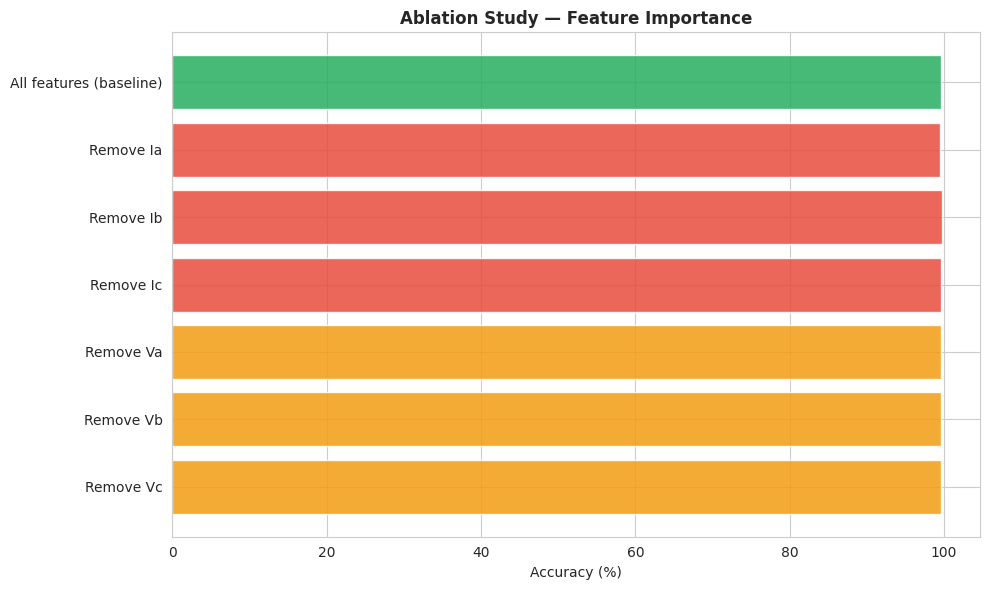

In [20]:
# ── Her feature'ı çıkarıp RF accuracy ölç ──
ablation_results = []
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_det_train_sc, y_det_train)
base_acc = accuracy_score(y_det_test, rf_base.predict(X_det_test_sc))
ablation_results.append({'Feature':'All features (baseline)', 'Accuracy':base_acc*100, 'Delta':'—'})
print(f'Baseline (all features): {base_acc*100:.2f}%')

for i, feat in enumerate(FEAT_COLS):
    idx = [j for j in range(len(FEAT_COLS)) if j != i]
    X_tr_abl = X_det_train_sc[:, idx]
    X_te_abl = X_det_test_sc[:, idx]
    rf_abl = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_abl.fit(X_tr_abl, y_det_train)
    acc_abl = accuracy_score(y_det_test, rf_abl.predict(X_te_abl))
    delta = acc_abl*100 - base_acc*100
    ablation_results.append({'Feature':f'Remove {feat}', 'Accuracy':acc_abl*100, 'Delta':f'{delta:+.2f}%'})
    print(f'Remove {feat}: {acc_abl*100:.2f}% (Δ{delta:+.2f}%)')

abl_df = pd.DataFrame(ablation_results)
print('\nAblation tamamlandı.')

# Görselleştir
fig, ax = plt.subplots(figsize=(10,6))
colors_abl = ['#27ae60'] + ['#e74c3c' if 'I' in r['Feature'] else '#f39c12'
              for r in ablation_results[1:]]
ax.barh(abl_df['Feature'][::-1], abl_df['Accuracy'][::-1], color=colors_abl[::-1], alpha=0.85)
ax.set_xlabel('Accuracy (%)')
ax.set_title('Ablation Study — Feature Importance', fontweight='bold')
plt.tight_layout(); plt.show()

---
## 🔗 Bölüm 8: Cross-Dataset Tutarlılık Testi

In [21]:
# ── Dataset 1'de Eğit, Dataset 2'de Test Et (binary) ──
# Dataset 2 labellerini binary'e çevir: No Fault=0, rest=1
y_cls_binary = (y_cls > 0).astype(int)

# Dataset 1 scaler ile Dataset 2'yi transform et
X_cls_scaled_d1 = scaler_det.transform(X_cls)

# En iyi detection modelini kullan
best_det_for_cross = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
best_det_for_cross.fit(X_det_train_sc, y_det_train)
y_cross_pred = best_det_for_cross.predict(X_cls_scaled_d1)
cross_acc = accuracy_score(y_cls_binary, y_cross_pred)

print('Cross-Dataset Tutarlılık Testi:')
print(f'  Eğitim: Dataset 1 (binary detection)')
print(f'  Test  : Dataset 2 (binary — No Fault=0, rest=1)')
print(f'  Random Forest Accuracy: {cross_acc*100:.2f}%')
print(classification_report(y_cls_binary, y_cross_pred, target_names=['Normal','Fault']))

Cross-Dataset Tutarlılık Testi:
  Eğitim: Dataset 1 (binary detection)
  Test  : Dataset 2 (binary — No Fault=0, rest=1)
  Random Forest Accuracy: 99.94%
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      2365
       Fault       1.00      1.00      1.00      5496

    accuracy                           1.00      7861
   macro avg       1.00      1.00      1.00      7861
weighted avg       1.00      1.00      1.00      7861



---
## 🧠 Bölüm 9: MLP Konfigürasyon Karşılaştırması

MLP konfigürasyonları test ediliyor...
  Linear + SGD              → 71.26%
  ReLU + Adam               → 99.50%
  Tanh + Adam               → 99.75%
  ReLU + Adaptive           → 99.75%


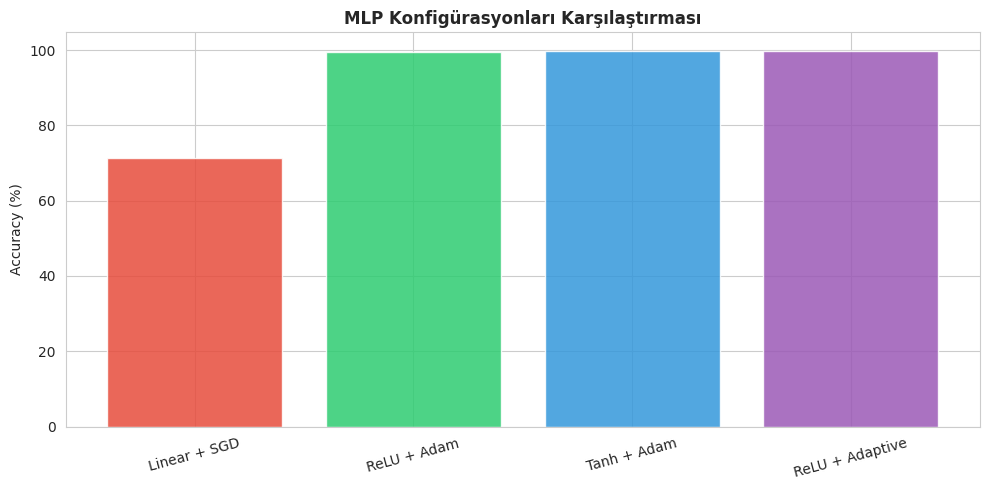

In [22]:
# ── 4 MLP Konfigürasyonu ──
mlp_configs = {
    'Linear + SGD'   : MLPClassifier(hidden_layer_sizes=(128,64), activation='identity',
                                      solver='sgd', max_iter=500, random_state=42),
    'ReLU + Adam'    : MLPClassifier(hidden_layer_sizes=(128,64), activation='relu',
                                      solver='adam', max_iter=500, random_state=42),
    'Tanh + Adam'    : MLPClassifier(hidden_layer_sizes=(128,64), activation='tanh',
                                      solver='adam', max_iter=500, random_state=42),
    'ReLU + Adaptive': MLPClassifier(hidden_layer_sizes=(256,128,64), activation='relu',
                                      solver='adam', learning_rate='adaptive',
                                      max_iter=500, random_state=42),
}
mlp_results = {}
print('MLP konfigürasyonları test ediliyor...')
for name, model in mlp_configs.items():
    model.fit(X_det_train_sc, y_det_train)
    acc = accuracy_score(y_det_test, model.predict(X_det_test_sc))
    mlp_results[name] = acc
    print(f'  {name:<25} → {acc*100:.2f}%')

best_mlp = max(mlp_results, key=mlp_results.get)
best_mlp_acc = mlp_results[best_mlp]*100

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(mlp_results.keys(), [v*100 for v in mlp_results.values()],
       color=['#e74c3c','#2ecc71','#3498db','#9b59b6'], alpha=0.85, edgecolor='white')
ax.set_ylabel('Accuracy (%)')
ax.set_title('MLP Konfigürasyonları Karşılaştırması', fontweight='bold')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

---
## 📊 Bölüm 10: Final Özet

In [23]:
# ── Final Özet Tablosu ──
print('=' * 70)
print('🎯 PROJE SONUÇLARI — ÖZET')
print('=' * 70)

det_best_row = summary_detection.iloc[0]
cls_best_row = summary_classification.iloc[0]

print(f'''
📌 DETECTION (Binary: Normal / Fault)
   Dataset        : {detect_df.shape[0]:,} satır | Normal: {n0} ({n0/len(y_det)*100:.1f}%) | Fault: {n1} ({n1/len(y_det)*100:.1f}%)
   En iyi model   : {det_best_row["Model"]}
   Accuracy       : {det_best_row["Accuracy"]:.2f}%
   F1 Score       : {det_best_row["F1"]:.2f}%

📌 CLASSIFICATION (6 Arıza Tipi)
   Dataset        : {X_cls.shape[0]:,} satır (geçerli)
   En iyi model   : {cls_best_row["Model"]}
   Accuracy       : {cls_best_row["Accuracy"]:.2f}%
   F1 Score       : {cls_best_row["F1"]:.2f}%

📌 GMM ANOMALİ TESPİTİ (Unsupervised)
   Optimal config  : n_components={best_gmm_n}, covariance_type={best_gmm_cov}
   Accuracy        : {gmm_final_acc*100:.2f}%

📌 PCA BOYUT İNDİRGEME
   %95 varyans için: {n_95} bileşen
   %99 varyans için: {n_99} bileşen

📌 MLP EN İYİ KONFİGÜRASYON
   Config   : {best_mlp}
   Accuracy : {best_mlp_acc:.2f}%

📌 CROSS-DATASET TUTARLILIK
   RF (D1→D2 binary): {cross_acc*100:.2f}%
''')

print('=' * 70)
print('DETECTION — Tam Tablo')
print(summary_detection[['Model','Accuracy','F1']].to_string(index=False))
print()
print('CLASSIFICATION — Tam Tablo')
print(summary_classification[['Model','Accuracy','F1']].to_string(index=False))
print('=' * 70)

🎯 PROJE SONUÇLARI — ÖZET

📌 DETECTION (Binary: Normal / Fault)
   Dataset        : 12,001 satır | Normal: 6505 (54.2%) | Fault: 5496 (45.8%)
   En iyi model   : Voting Ensemble
   Accuracy       : 99.75%
   F1 Score       : 99.75%

📌 CLASSIFICATION (6 Arıza Tipi)
   Dataset        : 7,861 satır (geçerli)
   En iyi model   : Random Forest
   Accuracy       : 88.24%
   F1 Score       : 88.24%

📌 GMM ANOMALİ TESPİTİ (Unsupervised)
   Optimal config  : n_components=2, covariance_type=full
   Accuracy        : 98.08%

📌 PCA BOYUT İNDİRGEME
   %95 varyans için: 4 bileşen
   %99 varyans için: 5 bileşen

📌 MLP EN İYİ KONFİGÜRASYON
   Config   : Tanh + Adam
   Accuracy : 99.75%

📌 CROSS-DATASET TUTARLILIK
   RF (D1→D2 binary): 99.94%

DETECTION — Tam Tablo
              Model  Accuracy        F1
    Voting Ensemble 99.750104 99.750121
  Gradient Boosting 99.666805 99.666829
          KNN (k=5) 99.666805 99.666829
      Random Forest 99.625156 99.625143
          SVM (RBF) 99.583507 99.583507
  